In [2]:
import pandas as pd
import os

# Set working directory to my project root
os.chdir(r'C:\Users\mokoe\Labour-Market-Trends-Business-Impact-Analysis')

# Read raw CSV
df = pd.read_csv('data/raw/status_in_employment.csv', header=None, skip_blank_lines=False)

# Drop fully empty rows
df = df.dropna(how='all')

# Drop note/metadata rows
mask = df.iloc[:, 0].astype(str).str.contains(
    'For all values|Due to rounding|Data in Thousands', na=False
)
df = df[~mask]

# Reset index
df = df.reset_index(drop=True)

# Save cleaned CSV
df.to_csv('data/cleaned/status_in_employment.csv', index=False, header=False)

print("Done! Cleaned CSV saved to data/cleaned/status_in_employment.csv")


Done! Cleaned CSV saved to data/cleaned/status_in_employment.csv


In [6]:
import pandas as pd
import sqlite3
import os

os.chdir(r'C:\Users\mokoe\Labour-Market-Trends-Business-Impact-Analysis')

# Load cleaned CSVs
underemployment = pd.read_csv('data/cleaned/underemployment_cleaned.csv', header=None)
status_in_employment = pd.read_csv('data/cleaned/status_in_employment_cleaned.csv', header=None)
hours_of_work = pd.read_csv('data/cleaned/hours_of_work_cleaned.csv', header=None)


# Create SQLite database in memory
conn = sqlite3.connect('data/labour_market.db')

# Load dataframes into SQL tables
underemployment.to_sql('underemployment', conn, if_exists='replace', index=False)
hours_of_work.to_sql('hours_of_work', conn, if_exists='replace', index=False)
status_in_employment.to_sql('status_in_employment', conn, if_exists='replace', index=False)

print("✅ Database created with 3 tables:")
print("   - underemployment")
print("   - hours_of_work")
print("   - status_in_employment")

✅ Database created with 3 tables:
   - underemployment
   - hours_of_work
   - status_in_employment


In [7]:
# Helper function to run SQL queries easily
def run_query(sql):
    return pd.read_sql_query(sql, conn)

# Q1: Which industry has the highest underemployment in Oct-Dec 2024?
q1 = run_query("""
    SELECT "0" as Industry, "5" as Oct_Dec_2024
    FROM underemployment
    WHERE "0" IN ('Agriculture','Mining','Manufacturing','Construction',
                  'Trade','Transport','Finance',
                  'Community and social services','Private households')
    ORDER BY CAST("5" AS FLOAT) DESC
""")
print("Top industries by underemployment (Oct-Dec 2024):")
print(q1)

# Q2: Gender gap in underemployment over time
q2 = run_query("""
    SELECT "0" as Category, "1" as Oct_Dec_2023, "5" as Oct_Dec_2024
    FROM underemployment
    WHERE "0" IN ('Women', 'Men')
""")
print("\nGender gap in underemployment:")
print(q2)

# Q3: How many people are working less than 15 hours per week?
q3 = run_query("""
    SELECT "0" as Category, "5" as Oct_Dec_2024
    FROM hours_of_work
    WHERE "0" LIKE '%less than 15%'
""")
print("\nWorking less than 15 hours per week (Oct-Dec 2024):")
print(q3)

Top industries by underemployment (Oct-Dec 2024):
                        Industry Oct_Dec_2024
0  Community and social services          210
1             Private households          200
2                          Trade          104
3                   Construction           91
4                        Finance           89
5                  Manufacturing           43
6                    Agriculture           27
7                      Transport           25
8                         Mining         None

Gender gap in underemployment:
  Category Oct_Dec_2023 Oct_Dec_2024
0    Women          386          409
1      Men          292          379
2    Women          3.4          3.5
3      Men          2.2          2.8
4    Women          5.2          5.4
5      Men          3.1          4.0

Working less than 15 hours per week (Oct-Dec 2024):
                              Category Oct_Dec_2024
0  Working less than 15 hours per week          509
1  Working less than 15 hours per week    

In [8]:
# Q4: Which occupation has the highest underemployment?
q4 = run_query("""
    SELECT "0" as Occupation, "5" as Oct_Dec_2024
    FROM underemployment
    WHERE "0" IN ('Manager','Professional','Technician','Clerk',
                  'Sales and services','Skilled agriculture',
                  'Craft and related trade','Plant and machine operator',
                  'Elementary','Domestic worker')
    ORDER BY CAST("5" AS FLOAT) DESC
""")
print("Underemployment by Occupation (Oct-Dec 2024):")
print(q4)

# Q5: Are people overworked? How many work more than 45 hours?
q5 = run_query("""
    SELECT "0" as Category, "5" as Oct_Dec_2024
    FROM hours_of_work
    WHERE "0" LIKE '%more than 45%'
""")
print("\nWorking more than 45 hours per week (Oct-Dec 2024):")
print(q5)

# Q6: Employment status breakdown - how many are self-employed vs employees?
q6 = run_query("""
    SELECT "0" as Status, "5" as Oct_Dec_2024
    FROM status_in_employment
    WHERE "0" IN ('Employee', 'Employer', 'Own-account worker', 'Unpaid household member')
""")
print("\nEmployment status breakdown (Oct-Dec 2024):")
print(q6)

# Q7: Is self-employment growing over time?
q7 = run_query("""
    SELECT "0" as Status, "1" as Oct_Dec_2023, "5" as Oct_Dec_2024, "8" as Pct_Change
    FROM status_in_employment
    WHERE "0" = 'Own-account worker'
""")
print("\nSelf-employment growth:")
print(q7)

Underemployment by Occupation (Oct-Dec 2024):
                   Occupation Oct_Dec_2024
0                  Elementary          324
1             Domestic worker          139
2     Craft and related trade          115
3          Sales and services           87
4                  Technician           39
5                     Manager           25
6                       Clerk           22
7  Plant and machine operator           21
8                Professional            9
9         Skilled agriculture            7

Working more than 45 hours per week (Oct-Dec 2024):
                              Category Oct_Dec_2024
0  Working more than 45 hours per week        4,529
1  Working more than 45 hours per week        1,523
2  Working more than 45 hours per week        3,006

Employment status breakdown (Oct-Dec 2024):
                     Status Oct_Dec_2024
0                  Employee       14,087
1                  Employer          966
2        Own-account worker        1,932
3   Unpaid 

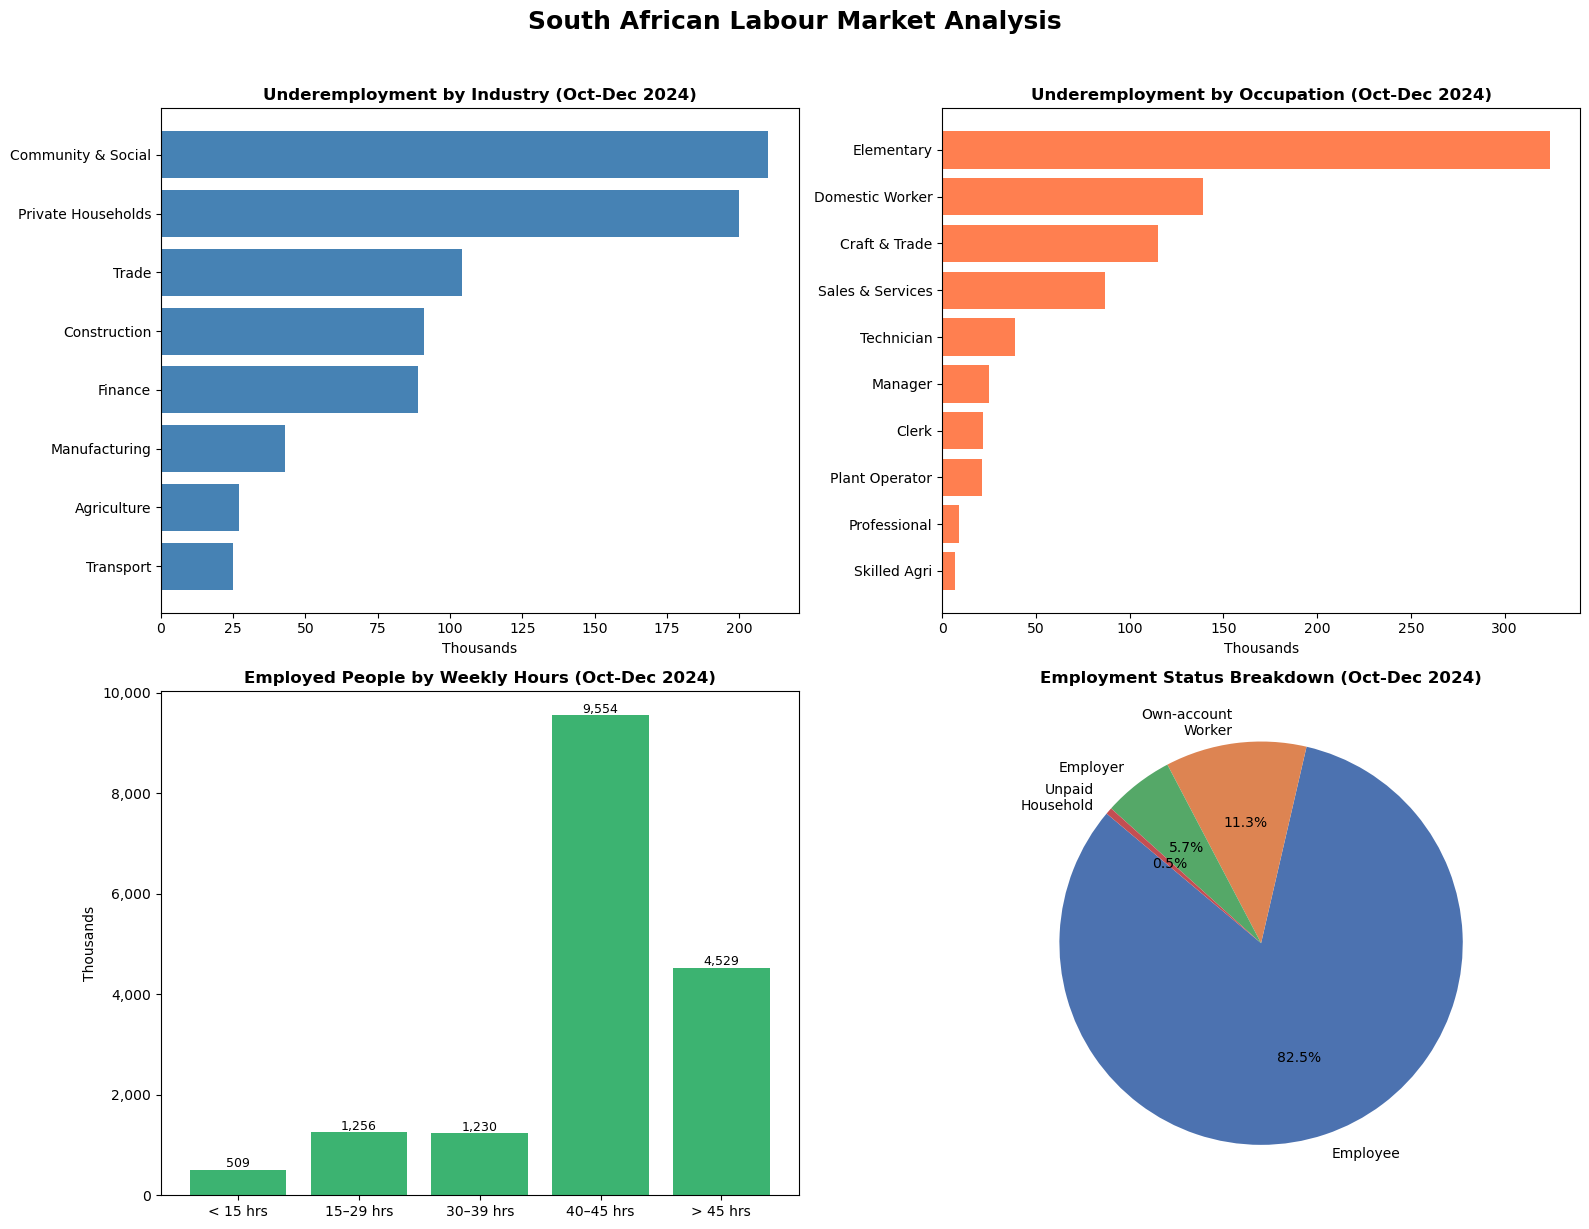

✅ Chart saved to visuals/charts/labour_market_overview.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

os.makedirs('visuals/charts', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('South African Labour Market Analysis', fontsize=18, fontweight='bold', y=1.02)

# --- Chart 1: Underemployment by Industry ---
industries = ['Community & Social', 'Private Households', 'Trade', 
              'Construction', 'Finance', 'Manufacturing', 'Agriculture', 'Transport']
values = [210, 200, 104, 91, 89, 43, 27, 25]

axes[0,0].barh(industries, values, color='steelblue')
axes[0,0].set_title('Underemployment by Industry (Oct-Dec 2024)', fontweight='bold')
axes[0,0].set_xlabel('Thousands')
axes[0,0].invert_yaxis()

# --- Chart 2: Underemployment by Occupation ---
occupations = ['Elementary', 'Domestic Worker', 'Craft & Trade', 
               'Sales & Services', 'Technician', 'Manager', 
               'Clerk', 'Plant Operator', 'Professional', 'Skilled Agri']
occ_values = [324, 139, 115, 87, 39, 25, 22, 21, 9, 7]

axes[0,1].barh(occupations, occ_values, color='coral')
axes[0,1].set_title('Underemployment by Occupation (Oct-Dec 2024)', fontweight='bold')
axes[0,1].set_xlabel('Thousands')
axes[0,1].invert_yaxis()

# --- Chart 3: Working Hours Breakdown ---
hours_categories = ['< 15 hrs', '15–29 hrs', '30–39 hrs', '40–45 hrs', '> 45 hrs']
hours_values = [509, 1256, 1230, 9554, 4529]

bars = axes[1,0].bar(hours_categories, hours_values, color='mediumseagreen')
axes[1,0].set_title('Employed People by Weekly Hours (Oct-Dec 2024)', fontweight='bold')
axes[1,0].set_ylabel('Thousands')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, hours_values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                   f'{val:,}', ha='center', fontsize=9)

# --- Chart 4: Employment Status Breakdown ---
statuses = ['Employee', 'Own-account\nWorker', 'Employer', 'Unpaid\nHousehold']
status_values = [14087, 1932, 966, 92]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

wedges, texts, autotexts = axes[1,1].pie(
    status_values, labels=statuses, autopct='%1.1f%%',
    colors=colors, startangle=140
)
axes[1,1].set_title('Employment Status Breakdown (Oct-Dec 2024)', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/charts/labour_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to visuals/charts/labour_market_overview.png")

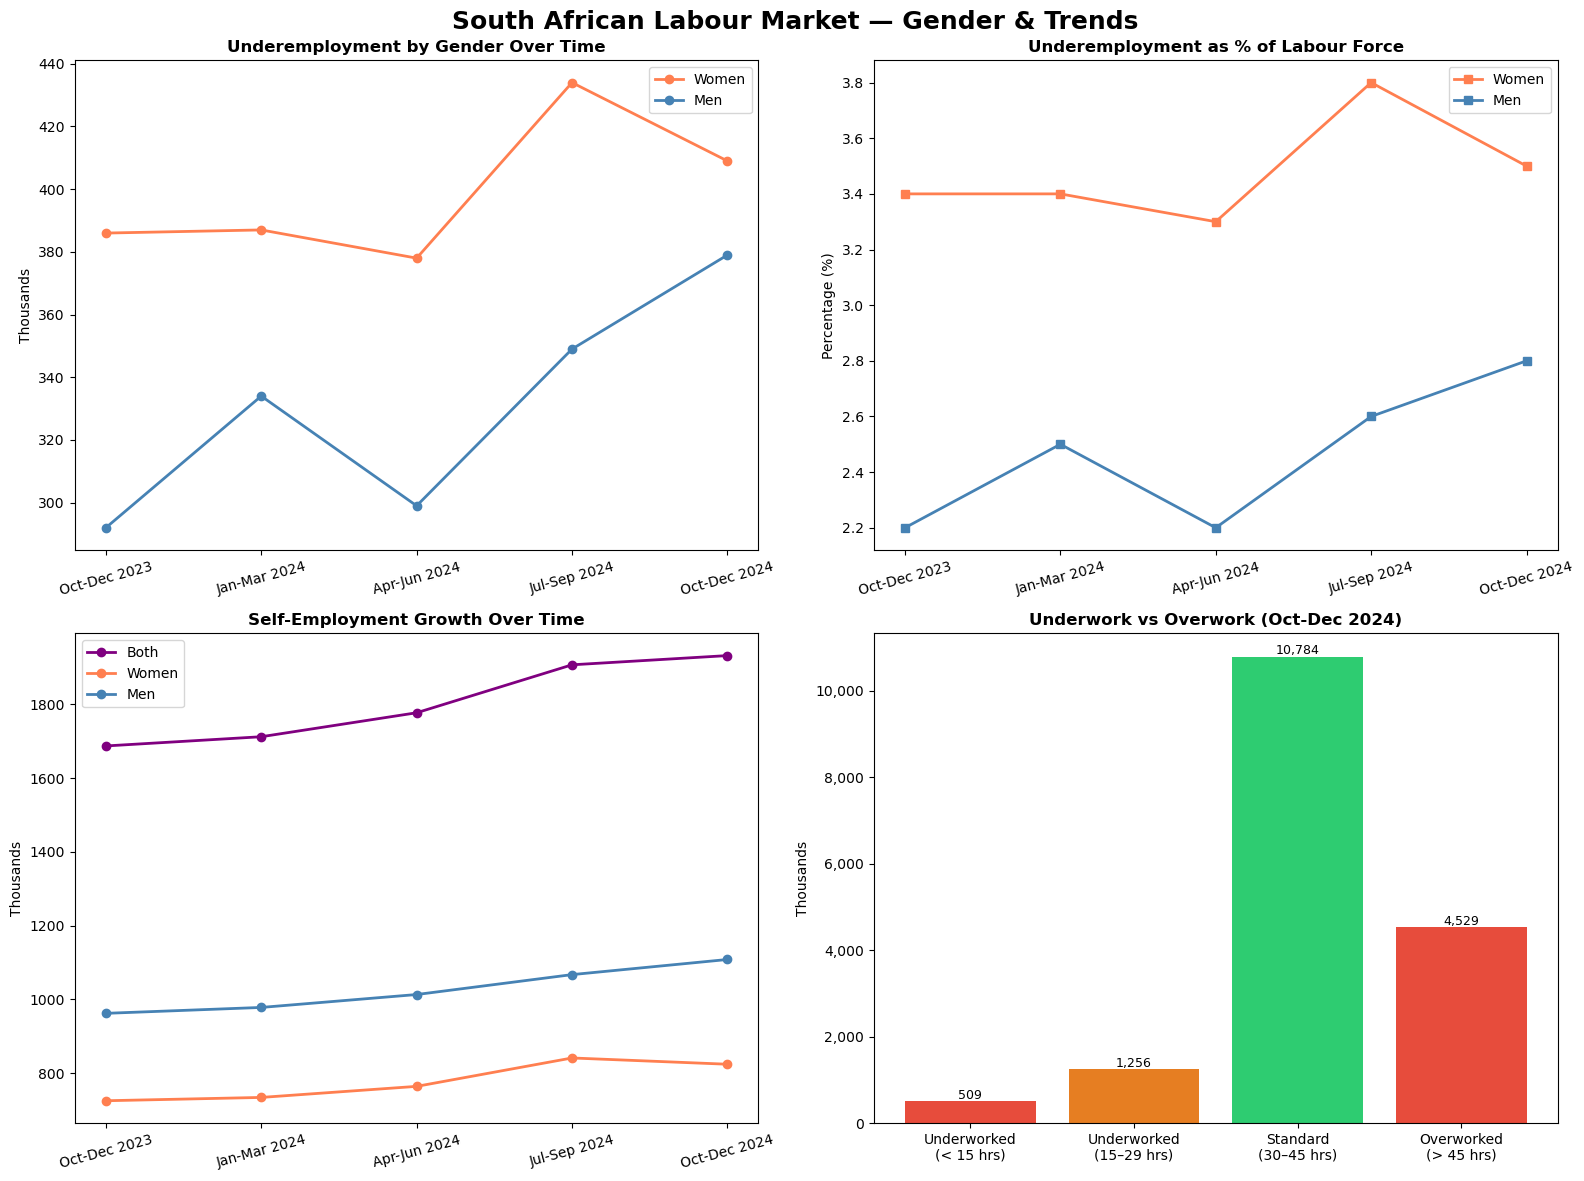

✅ Chart saved to visuals/charts/labour_market_trends.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('South African Labour Market — Gender & Trends', fontsize=18, fontweight='bold')

quarters = ['Oct-Dec 2023', 'Jan-Mar 2024', 'Apr-Jun 2024', 'Jul-Sep 2024', 'Oct-Dec 2024']

# --- Chart 5: Gender Gap Over Time (actual numbers) ---
women = [386, 387, 378, 434, 409]
men = [292, 334, 299, 349, 379]

axes[0,0].plot(quarters, women, marker='o', color='coral', label='Women', linewidth=2)
axes[0,0].plot(quarters, men, marker='o', color='steelblue', label='Men', linewidth=2)
axes[0,0].set_title('Underemployment by Gender Over Time', fontweight='bold')
axes[0,0].set_ylabel('Thousands')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=15)

# --- Chart 6: Underemployment as % of Labour Force ---
women_pct = [3.4, 3.4, 3.3, 3.8, 3.5]
men_pct = [2.2, 2.5, 2.2, 2.6, 2.8]

axes[0,1].plot(quarters, women_pct, marker='s', color='coral', label='Women', linewidth=2)
axes[0,1].plot(quarters, men_pct, marker='s', color='steelblue', label='Men', linewidth=2)
axes[0,1].set_title('Underemployment as % of Labour Force', fontweight='bold')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=15)

# --- Chart 7: Self-Employment Growth Over Time ---
self_emp_both = [1687, 1712, 1777, 1907, 1932]
self_emp_women = [725, 734, 764, 841, 824]
self_emp_men = [962, 978, 1013, 1067, 1108]

axes[1,0].plot(quarters, self_emp_both, marker='o', color='purple', label='Both', linewidth=2)
axes[1,0].plot(quarters, self_emp_women, marker='o', color='coral', label='Women', linewidth=2)
axes[1,0].plot(quarters, self_emp_men, marker='o', color='steelblue', label='Men', linewidth=2)
axes[1,0].set_title('Self-Employment Growth Over Time', fontweight='bold')
axes[1,0].set_ylabel('Thousands')
axes[1,0].legend()
axes[1,0].tick_params(axis='x', rotation=15)

# --- Chart 8: Overwork vs Underwork ---
categories = ['Underworked\n(< 15 hrs)', 'Underworked\n(15–29 hrs)', 'Standard\n(30–45 hrs)', 'Overworked\n(> 45 hrs)']
both_sexes = [509, 1256, 10784, 4529]
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#e74c3c']

bars = axes[1,1].bar(categories, both_sexes, color=colors)
axes[1,1].set_title('Underwork vs Overwork (Oct-Dec 2024)', fontweight='bold')
axes[1,1].set_ylabel('Thousands')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, both_sexes):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                   f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('visuals/charts/labour_market_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to visuals/charts/labour_market_trends.png")

In [11]:
import pandas as pd
import os

os.chdir(r'C:\Users\mokoe\Labour-Market-Trends-Business-Impact-Analysis')

# Check what the cleaned files actually look like
for filename in ['underemployment_cleaned.csv', 'hours_of_work_cleaned.csv', 'status_in_employment_cleaned.csv']:
    print(f"\n=== {filename} ===")
    df = pd.read_csv(f'data/cleaned/{filename}', nrows=5)
    print(df.head())
    print("Columns:", df.columns.tolist())


=== underemployment_cleaned.csv ===
                                       Unnamed: 0  Oct-Dec 2023  Jan-Mar 2024  \
0                                      Both sexes         678.0         722.0   
1                                           Women         386.0         387.0   
2                                             Men         292.0         334.0   
3  As percentage of the labour force (both sexes)           2.8           2.9   
4                                           Women           3.4           3.4   

   Apr-Jun 2024  Jul-Sep 2024  Oct-Dec 2024  Qtr-to-qtr change  \
0         677.0         783.0         788.0                5.0   
1         378.0         434.0         409.0              -25.0   
2         299.0         349.0         379.0               29.0   
3           2.7           3.1           3.1                0.0   
4           3.3           3.8           3.5               -0.3   

   Year-on-year change  Qtr-to-qtr change.1  Year-on-year change.1  
0         

In [12]:
import pandas as pd
import os

os.chdir(r'C:\Users\mokoe\Labour-Market-Trends-Business-Impact-Analysis')

def fix_headers(input_path, output_path):
    df = pd.read_csv(input_path)
    # Rename the unnamed first column to Category
    df.rename(columns={'Unnamed: 0': 'Category'}, inplace=True)
    df.to_csv(output_path, index=False)
    print(f"✅ Fixed: {output_path}")

fix_headers('data/cleaned/underemployment_cleaned.csv', 'data/cleaned/underemployment_cleaned.csv')
fix_headers('data/cleaned/hours_of_work_cleaned.csv', 'data/cleaned/hours_of_work_cleaned.csv')
fix_headers('data/cleaned/status_in_employment_cleaned.csv', 'data/cleaned/status_in_employment_cleaned.csv')

✅ Fixed: data/cleaned/underemployment_cleaned.csv
✅ Fixed: data/cleaned/hours_of_work_cleaned.csv
✅ Fixed: data/cleaned/status_in_employment_cleaned.csv


In [1]:
import pandas as pd
import os

os.chdir(r'C:\Users\mokoe\Labour-Market-Trends-Business-Impact-Analysis')

def fix_csv(filename):
    df = pd.read_csv(f'data/cleaned/{filename}')
    # Rename unnamed column
    df.rename(columns={'Unnamed: 0': 'Category'}, inplace=True)
    # Force all columns except Category to numeric
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    df.to_csv(f'data/cleaned/{filename}', index=False)
    print(f"✅ {filename}")
    print(df.dtypes)
    print()

fix_csv('underemployment_cleaned.csv')
fix_csv('hours_of_work_cleaned.csv')
fix_csv('status_in_employment_cleaned.csv')

✅ underemployment_cleaned.csv
Category                  object
Oct-Dec 2023             float64
Jan-Mar 2024             float64
Apr-Jun 2024             float64
Jul-Sep 2024             float64
Oct-Dec 2024             float64
Qtr-to-qtr change        float64
Year-on-year change      float64
Qtr-to-qtr change.1      float64
Year-on-year change.1    float64
dtype: object

✅ hours_of_work_cleaned.csv
Category                  object
Oct-Dec 2023               int64
Jan-Mar 2024               int64
Apr-Jun 2024               int64
Jul-Sep 2024               int64
Oct-Dec 2024               int64
Qtr-to-qtr change          int64
Year-on-year change        int64
Qtr-to-qtr change.1      float64
Year-on-year change.1    float64
dtype: object

✅ status_in_employment_cleaned.csv
Category                  object
Oct-Dec 2023               int64
Jan-Mar 2024               int64
Apr-Jun 2024               int64
Jul-Sep 2024               int64
Oct-Dec 2024               int64
Qtr-to-qtr change  

In [5]:
import os

os.chdir(r'C:\Users\mokoe\Labour-Market-Trends-Business-Impact-Analysis')

for f in os.listdir('data/cleaned'):
    print(f)

.gitkeep
hours_of_work_cleaned.csv
status_in_employment.csv
underemployment_cleaned.csv
